In [16]:
import pandas as pd
import numpy as np
import json
import os
from glob import glob

In [17]:
import ast

df_raw = pd.read_csv('data_15-6-26.csv', index_col=0)

# Parse string-tuple column names into a MultiIndex: (model, metric)
df_raw.columns = pd.MultiIndex.from_tuples([ast.literal_eval(c) for c in df_raw.columns])

# Stack model level into rows → each row becomes (task, model) with metric columns
df = df_raw.stack(level=0).reset_index()
df.columns.name = None
df = df.rename(columns={'level_0': 'task', 'level_1': 'model'})

# Strip '%' and leading '+' from percentage strings, convert to float
def pct_to_float(s):
    return float(str(s).strip('%').lstrip('+'))

df['base score'] = df['Base'].apply(pct_to_float)
df['performance'] = df['Performance'].apply(pct_to_float)
# Use nullable Int64 to handle NaN rows (e.g. candidate count == 0)
df['best skip layer'] = df['Best Skip Layer'].astype('Int64')
df['candidate count'] = df['Candidate Count'].astype('Int64')

df = df[['task', 'model', 'best skip layer', 'base score', 'performance', 'candidate count']]
df


,task,model,best skip layer,base score,performance,candidate count
0,global_mmlu_full_ar_formal_logic,google/gemma-3-270m-it,11,23.02,13.49,10
1,global_mmlu_full_ar_formal_logic,google/gemma-3-1b-it,21,35.71,1.59,1
2,global_mmlu_full_ar_formal_logic,meta-llama/Llama-3.2-1B-Instruct,13,27.78,7.94,1
3,global_mmlu_full_ar_formal_logic,meta-llama/Llama-3.2-3B-Instruct,24,26.98,7.94,11
4,global_mmlu_full_ar_formal_logic,Qwen/Qwen3-1.7B,18,34.13,5.56,11
...,...,...,...,...,...,...
5467,NaN,Qwen/Qwen3-1.7B,<NA>,NaN,3.60,<NA>
5468,NaN,Qwen/Qwen3-4B,<NA>,NaN,2.86,<NA>
5469,NaN,Qwen/Qwen3-8B,<NA>,NaN,2.49,<NA>
5470,NaN,allenai/OLMo-2-0425-1B-Instruct,<NA>,NaN,4.12,<NA>


In [18]:
# Only take tasks that has 'mmlu', 'anli', 'toxigen', and 'hellaswag'. 
# Task is a string, so just check whether the tasks string contained in the task column as a substring.
desired_tasks = ['mmlu', 'anli', 'toxigen', 'hellaswag']
df = df[df['task'].str.contains('|'.join(desired_tasks))]
df


,task,model,best skip layer,base score,performance,candidate count
0,global_mmlu_full_ar_formal_logic,google/gemma-3-270m-it,11,23.02,13.49,10
1,global_mmlu_full_ar_formal_logic,google/gemma-3-1b-it,21,35.71,1.59,1
2,global_mmlu_full_ar_formal_logic,meta-llama/Llama-3.2-1B-Instruct,13,27.78,7.94,1
3,global_mmlu_full_ar_formal_logic,meta-llama/Llama-3.2-3B-Instruct,24,26.98,7.94,11
4,global_mmlu_full_ar_formal_logic,Qwen/Qwen3-1.7B,18,34.13,5.56,11
...,...,...,...,...,...,...
5170,anli_r3,Qwen/Qwen3-1.7B,25,42.75,0.67,1
5171,anli_r3,Qwen/Qwen3-4B,25,51.17,1.50,8
5172,anli_r3,Qwen/Qwen3-8B,31,55.50,1.17,4
5173,anli_r3,allenai/OLMo-2-0425-1B-Instruct,13,38.58,-0.33,0


In [19]:
has_empty = df.groupby('model').apply(lambda g: g.isnull().any(axis=1).any()).to_dict()
has_empty

{'Qwen/Qwen3-1.7B': False,
 'Qwen/Qwen3-4B': False,
 'Qwen/Qwen3-8B': False,
 'allenai/OLMo-2-0425-1B-Instruct': False,
 'allenai/OLMo-2-1124-7B-Instruct': True,
 'google/gemma-3-1b-it': False,
 'google/gemma-3-270m-it': True,
 'meta-llama/Llama-3.2-1B-Instruct': False,
 'meta-llama/Llama-3.2-3B-Instruct': True}

In [20]:
agg = (
    df.dropna()
    .groupby('model')[['base score', 'performance']]
    .agg(['mean', 'var', 'std'])
)
agg.columns = [f"{col.replace(' ', '-')}_{stat}" for col, stat in agg.columns]
agg['has_empty'] = agg.index.map(has_empty)
agg

,base-score_mean,base-score_var,base-score_std,performance_mean,performance_var,performance_std,has_empty
model,,,,,,,
Qwen/Qwen3-1.7B,45.904070,139.641360,11.816995,3.366800,8.741151,2.956544,False
Qwen/Qwen3-4B,56.404991,218.686408,14.788050,2.765287,5.568418,2.359750,False
Qwen/Qwen3-8B,62.861983,215.740099,14.688094,2.410522,3.697383,1.922858,False
allenai/OLMo-2-0425-1B-Instruct,31.010504,50.842481,7.130391,4.112991,15.833278,3.979105,False
allenai/OLMo-2-1124-7B-Instruct,39.654642,165.858074,12.878590,3.595170,6.596800,2.568424,True
google/gemma-3-1b-it,35.604730,64.900200,8.056066,3.797374,10.376152,3.221204,False
google/gemma-3-270m-it,24.552005,15.789507,3.973601,7.834678,31.634512,5.624457,True
meta-llama/Llama-3.2-1B-Instruct,37.599235,83.667236,9.146980,2.186052,10.207520,3.194921,False
meta-llama/Llama-3.2-3B-Instruct,46.826498,163.873071,12.801292,3.061585,6.932835,2.633028,True


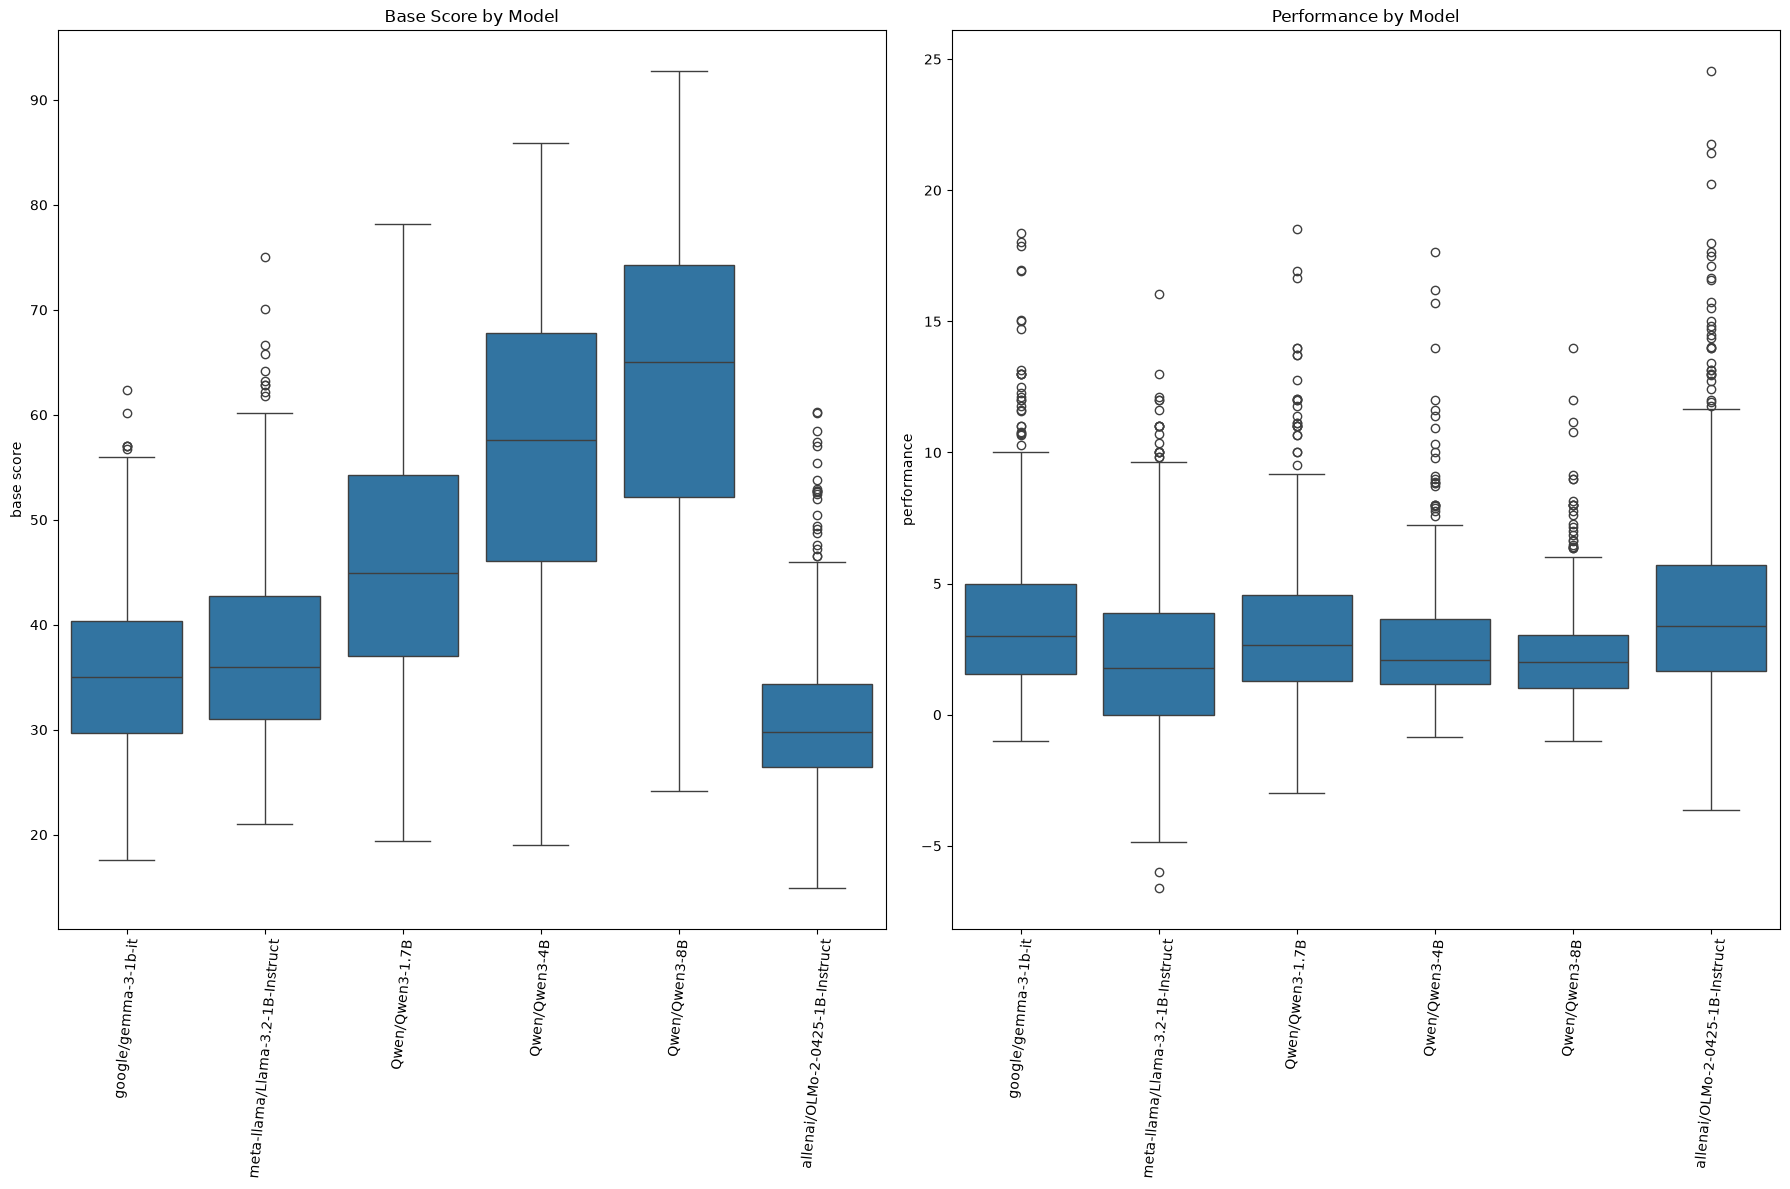

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

complete_models = [m for m, empty in has_empty.items() if not empty]
df_plot = df[df['model'].isin(complete_models)]

fig, axes = plt.subplots(1, 2, figsize=(18, 12))

sns.boxplot(data=df_plot, x='model', y='base score', ax=axes[0])
axes[0].set_title('Base Score by Model')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=85)

sns.boxplot(data=df_plot, x='model', y='performance', ax=axes[1])
axes[1].set_title('Performance by Model')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=85)

fig.tight_layout()
plt.show()